# Pipeline de Modelagem Preditiva — Random Forest

Este notebook implementa a pipeline completa de modelagem preditiva para prever o número de internações por doenças respiratórias no dia D0 no Rio de Janeiro, utilizando features temporais, sazonais e atmosféricas.

**Modelo:** Random Forest Regressor

**Entrada:** `Data/GoldData/modelDataset.parquet`

**Etapas principais:**
1. Carregamento e inspeção
2. Preparação e divisão temporal
3. Baselines
4. Treinamento com diferentes estratégias de alvo
5. Ajuste de hiperparâmetros
6. Avaliação final e diagnósticos
7. Importância das features
8. Consolidação e salvamento

## 1. Imports e Configuração

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

BASE_DIR = Path('../../Data')
OUTPUT_DIR = BASE_DIR / 'GoldData' / 'ModelResults'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Setup concluído.')

Setup concluído.


## 2. Carregamento e Inspeção do Dataset

In [19]:
PATH_DATASET = BASE_DIR / 'GoldData' / 'modelDataset.parquet'
df = pd.read_parquet(PATH_DATASET)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Período: {df["data"].min().date()} a {df["data"].max().date()}')
print(f'\nColunas ({len(df.columns)}):')
for col in df.columns:
    print(f'  {col}: {df[col].dtype}, NaN={df[col].isnull().sum()}')

display(df.head())

Shape: (2387, 37)
Período: 2012-06-19 a 2018-12-31

Colunas (37):
  data: datetime64[us], NaN=0
  target: int64, NaN=0
  lag_1: float64, NaN=0
  lag_2: float64, NaN=0
  lag_3: float64, NaN=0
  lag_7: float64, NaN=0
  lag_14: float64, NaN=0
  lag_21: float64, NaN=0
  lag_28: float64, NaN=0
  lag_30: float64, NaN=0
  lag_365: float64, NaN=0
  rolling_mean_7: float64, NaN=0
  rolling_mean_14: float64, NaN=0
  rolling_mean_30: float64, NaN=0
  rolling_std_7: float64, NaN=0
  rolling_std_30: float64, NaN=0
  mes_sin: float64, NaN=0
  mes_cos: float64, NaN=0
  dia_semana_sin: float64, NaN=0
  dia_semana_cos: float64, NaN=0
  semana_epi_sin: float64, NaN=0
  semana_epi_cos: float64, NaN=0
  fim_de_semana: int64, NaN=0
  estacao: int64, NaN=0
  dummy_periodo_pico_sazonal: int64, NaN=0
  stl365_seasonal: float64, NaN=0
  stl365_resid_vol30: float64, NaN=0
  stl365_season_amp: float64, NaN=0
  o3_ma_120d_shift_1d: float64, NaN=0
  no_ma_30d_shift_1d: float64, NaN=0
  co_ma_120d_shift_1d: float64

,data,target,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_28,lag_30,...,stl365_season_amp,o3_ma_120d_shift_1d,no_ma_30d_shift_1d,co_ma_120d_shift_1d,so2_ma_150d_shift_21d,nox_ma_21d_shift_1d,no2_lag0,pm2_5_ma_30d_shift_1d,temp_ma_14d_shift_1d,ur_ma_60d_shift_1d
0,2012-06-19,62,69.0,39.0,43.0,80.0,79.0,76.0,83.0,50.0,...,80.728641,27.864008,34.426167,0.386750,6.283987,78.261952,48.495,20.093167,23.336571,78.910850
1,2012-06-20,68,62.0,69.0,39.0,51.0,65.0,82.0,81.0,78.0,...,80.725302,27.736283,35.443600,0.389867,6.326227,76.690238,58.166,21.107767,23.319714,78.831667
2,2012-06-21,45,68.0,62.0,69.0,59.0,38.0,49.0,82.0,83.0,...,80.726603,27.571792,35.709500,0.394358,6.335953,76.167238,31.730,22.142400,23.303571,78.921333
3,2012-06-22,61,45.0,68.0,62.0,58.0,36.0,62.0,85.0,81.0,...,80.744914,27.376708,35.327033,0.395258,6.329067,75.282905,31.691,22.322267,23.401286,78.881400
4,2012-06-23,50,61.0,45.0,68.0,43.0,34.0,48.0,49.0,82.0,...,80.694711,27.121000,34.933433,0.395200,6.332160,74.783238,26.043,22.093100,23.616643,78.867017


## 3. Preparação para Modelagem

Separa a coluna de data (referência temporal), a variável alvo e as features preditoras. A coluna `data` não entra no modelo — serve apenas para ordenação e divisão temporal.

In [20]:
# Coluna alvo e colunas que não são features
TARGET_COL = 'target'
NON_FEATURE_COLS = ['data', 'target']

feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
dates = df['data']
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'\nAlvo: {TARGET_COL}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nNaN em X: {X.isnull().sum().sum()}')
print(f'NaN em y: {y.isnull().sum()}')

# Verifica que todas as features são numéricas
assert X.select_dtypes(include='number').shape[1] == X.shape[1], \
    'Existem colunas não numéricas em X!'
print('\nTodas as features são numéricas. OK.')

Features (35): ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30', 'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos', 'semana_epi_sin', 'semana_epi_cos', 'fim_de_semana', 'estacao', 'dummy_periodo_pico_sazonal', 'stl365_seasonal', 'stl365_resid_vol30', 'stl365_season_amp', 'o3_ma_120d_shift_1d', 'no_ma_30d_shift_1d', 'co_ma_120d_shift_1d', 'so2_ma_150d_shift_21d', 'nox_ma_21d_shift_1d', 'no2_lag0', 'pm2_5_ma_30d_shift_1d', 'temp_ma_14d_shift_1d', 'ur_ma_60d_shift_1d']

Alvo: target
X shape: (2387, 35)
y shape: (2387,)

NaN em X: 0
NaN em y: 0

Todas as features são numéricas. OK.


## 4. Divisão Temporal

Divisão cronológica: **treino → validação → teste**.

A série cobre 2012-12-31 a 2018-12-31 (~6 anos). Proporção:
- **Treino:** ~70% — primeiros ~4 anos
- **Validação:** ~15% — ~1 ano seguinte  
- **Teste:** ~15% — último ~1 ano

Nenhuma aleatoriedade: divisão puramente temporal.

In [21]:
# Datas de corte para divisão temporal
TRAIN_END = pd.Timestamp('2016-12-31')
VAL_END = pd.Timestamp('2017-12-31')

mask_train = dates <= TRAIN_END
mask_val = (dates > TRAIN_END) & (dates <= VAL_END)
mask_test = dates > VAL_END

X_train, y_train, dates_train = X[mask_train], y[mask_train], dates[mask_train]
X_val, y_val, dates_val = X[mask_val], y[mask_val], dates[mask_val]
X_test, y_test, dates_test = X[mask_test], y[mask_test], dates[mask_test]

print('Divisão temporal:')
for name, d, x_s in [('Treino', dates_train, X_train),
                      ('Validação', dates_val, X_val),
                      ('Teste', dates_test, X_test)]:
    print(f'  {name}: {d.min().date()} a {d.max().date()} '
          f'({len(x_s)} dias, {len(x_s)/len(X)*100:.1f}%)')

# Verifica que não há sobreposição
assert dates_train.max() < dates_val.min(), 'Sobreposição treino-validação!'
assert dates_val.max() < dates_test.min(), 'Sobreposição validação-teste!'
print('\nSem sobreposição entre conjuntos. OK.')

Divisão temporal:
  Treino: 2012-06-19 a 2016-12-31 (1657 dias, 69.4%)
  Validação: 2017-01-01 a 2017-12-31 (365 dias, 15.3%)
  Teste: 2018-01-01 a 2018-12-31 (365 dias, 15.3%)

Sem sobreposição entre conjuntos. OK.


## 5. Modelos Baseline

Referências simples para calibrar a expectativa de desempenho:
- **Persistência (lag_1):** valor de internações do dia anterior
- **Média móvel 7 dias:** média dos últimos 7 dias
- **Mesmo dia da semana anterior (lag_7):** valor de 7 dias atrás

In [22]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # Evita divisão por zero
    denominator = np.where(denominator == 0, 1, denominator)
    return np.mean(np.abs(y_true - y_pred) / denominator) * 100


def evaluate(y_true, y_pred, label=''):
    """Calcula e retorna métricas de regressão."""
    metrics = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred)
    }
    if label:
        print(f'\n--- {label} ---')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')
    return metrics


# Baselines avaliados no conjunto de validação
baselines = {}

# Baseline 1: Persistência (lag_1) — previsão = internações do dia anterior
baselines['Persistência (lag_1)'] = evaluate(
    y_val.values, X_val['lag_1'].values, 'Persistência (lag_1)'
)

# Baseline 2: Média móvel 7 dias
baselines['Média Móvel 7d'] = evaluate(
    y_val.values, X_val['rolling_mean_7'].values, 'Média Móvel 7 dias'
)

# Baseline 3: Mesmo dia da semana anterior (lag_7)
baselines['Lag 7 (mesmo dia semana)'] = evaluate(
    y_val.values, X_val['lag_7'].values, 'Lag 7 (mesmo dia semana)'
)

df_baselines = pd.DataFrame(baselines).T
print('\n=== Resumo Baselines (Validação) ===')
display(df_baselines.round(4))


--- Persistência (lag_1) ---
  MAE: 8.2466
  RMSE: 10.4142
  R²: -0.0333
  sMAPE: 31.6963

--- Média Móvel 7 dias ---
  MAE: 6.3886
  RMSE: 7.9771
  R²: 0.3937
  sMAPE: 24.9975

--- Lag 7 (mesmo dia semana) ---
  MAE: 6.8877
  RMSE: 8.7143
  R²: 0.2765
  sMAPE: 27.0983

=== Resumo Baselines (Validação) ===


,MAE,RMSE,R²,sMAPE
Persistência (lag_1),8.2466,10.4142,-0.0333,31.6963
Média Móvel 7d,6.3886,7.9771,0.3937,24.9975
Lag 7 (mesmo dia semana),6.8877,8.7143,0.2765,27.0983


## 6. Pipeline de Pré-processamento

Random Forest não necessita de escalonamento. A pipeline inclui apenas imputação de medianas como precaução, caso exista algum valor ausente residual.

In [23]:
def make_rf_pipeline(rf_params=None):
    """Cria pipeline com imputador + Random Forest."""
    if rf_params is None:
        rf_params = {}
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('rf', RandomForestRegressor(random_state=SEED, n_jobs=-1, **rf_params))
    ])


print('Pipeline de pré-processamento definida.')

Pipeline de pré-processamento definida.


## 7. Estratégias de Transformação da Variável Alvo

Compararemos três estratégias:

| Estratégia | Descrição |
|---|---|
| **A** | Alvo original |
| **B** | `log1p(y)` |
| **C** | `log1p(y)` + detrend (tendência linear estimada no treino) |

### Detrend (Estratégia C)

A tendência é estimada **apenas com dados de treino** via regressão linear no índice temporal (número de dias desde o início da série). Essa mesma função é reaplicada em validação e teste para somar/subtrair a tendência sem vazamento de informação.

In [24]:
# Índice temporal: número de dias desde o início da série
# Usado como variável independente para estimar a tendência
t0 = dates.min()
t_all = (dates - t0).dt.days.values.astype(float)

t_train = t_all[mask_train]
t_val = t_all[mask_val]
t_test = t_all[mask_test]

# --- Estratégia A: alvo original ---
y_train_A = y_train.values.astype(float)
y_val_A = y_val.values.astype(float)
y_test_A = y_test.values.astype(float)

# --- Estratégia B: log1p ---
y_train_B = np.log1p(y_train.values.astype(float))
y_val_B = np.log1p(y_val.values.astype(float))
y_test_B = np.log1p(y_test.values.astype(float))

# --- Estratégia C: log1p + detrend ---
# Estima tendência linear SOMENTE com dados de treino
y_train_log = np.log1p(y_train.values.astype(float))
trend_coeffs = np.polyfit(t_train, y_train_log, deg=1)  # [slope, intercept]
trend_fn = np.poly1d(trend_coeffs)

print(f'Tendência estimada no treino: slope={trend_coeffs[0]:.6f}, '
      f'intercept={trend_coeffs[1]:.4f}')

# Remove tendência de cada conjunto
y_train_C = y_train_log - trend_fn(t_train)
y_val_C = np.log1p(y_val.values.astype(float)) - trend_fn(t_val)
y_test_C = np.log1p(y_test.values.astype(float)) - trend_fn(t_test)

# Funções de reconstrução (escala original)
def inverse_A(y_pred):
    """Estratégia A: já está na escala original."""
    return y_pred

def inverse_B(y_pred_log):
    """Estratégia B: desfaz log1p."""
    return np.expm1(y_pred_log)

def inverse_C(y_pred_detrended, t_values):
    """Estratégia C: soma tendência e desfaz log1p."""
    return np.expm1(y_pred_detrended + trend_fn(t_values))

print('\nEstatísticas do alvo em cada estratégia (treino):')
for name, vals in [('A (original)', y_train_A), ('B (log1p)', y_train_B),
                    ('C (log1p+detrend)', y_train_C)]:
    print(f'  {name}: mean={vals.mean():.4f}, std={vals.std():.4f}, '
          f'min={vals.min():.4f}, max={vals.max():.4f}')

Tendência estimada no treino: slope=-0.000160, intercept=3.5999

Estatísticas do alvo em cada estratégia (treino):
  A (original): mean=33.5963, std=13.5045, min=6.0000, max=96.0000
  B (log1p): mean=3.4671, std=0.3994, min=1.9459, max=4.5747
  C (log1p+detrend): mean=0.0000, std=0.3920, min=-1.5557, max=1.1455


## 8. Treinamento e Comparação das Estratégias

Treina um Random Forest com hiperparâmetros padrão para cada uma das três estratégias. A comparação é feita na **escala original** (internações) usando o conjunto de validação.

As estratégias **B** e **C** são levadas adiante para ajuste de hiperparâmetros e avaliação final, permitindo comparação lado a lado.


In [25]:
strategies = {}

# --- Estratégia A: alvo original ---
print('Treinando Estratégia A (alvo original)...')
pipe_A = make_rf_pipeline({'n_estimators': 300})
pipe_A.fit(X_train, y_train_A)
pred_val_A = inverse_A(pipe_A.predict(X_val))
strategies['A: Original'] = evaluate(y_val.values, pred_val_A, 'Estratégia A')
strategies['A: Original']['pipeline'] = pipe_A

# --- Estratégia B: log1p ---
print('\nTreinando Estratégia B (log1p)...')
pipe_B = make_rf_pipeline({'n_estimators': 300})
pipe_B.fit(X_train, y_train_B)
pred_val_B = inverse_B(pipe_B.predict(X_val))
strategies['B: Log1p'] = evaluate(y_val.values, pred_val_B, 'Estratégia B')
strategies['B: Log1p']['pipeline'] = pipe_B

# --- Estratégia C: log1p + detrend ---
print('\nTreinando Estratégia C (log1p + detrend)...')
pipe_C = make_rf_pipeline({'n_estimators': 300})
pipe_C.fit(X_train, y_train_C)
pred_val_C = inverse_C(pipe_C.predict(X_val), t_val)
strategies['C: Log1p+Detrend'] = evaluate(y_val.values, pred_val_C, 'Estratégia C')
strategies['C: Log1p+Detrend']['pipeline'] = pipe_C

# Tabela comparativa
df_compare = pd.DataFrame(
    {k: {m: v[m] for m in ['MAE', 'RMSE', 'R²', 'sMAPE']} for k, v in strategies.items()}
).T
print('\n=== Comparação de Estratégias (Validação — escala original) ===')
display(df_compare.round(4))
print('\nEstratégias B e C serão levadas ao ajuste de hiperparâmetros.')

Treinando Estratégia A (alvo original)...

--- Estratégia A ---
  MAE: 5.2933
  RMSE: 6.7112
  R²: 0.5709
  sMAPE: 20.7928

Treinando Estratégia B (log1p)...

--- Estratégia B ---
  MAE: 5.2391
  RMSE: 6.6558
  R²: 0.5780
  sMAPE: 20.7543

Treinando Estratégia C (log1p + detrend)...

--- Estratégia C ---
  MAE: 6.1835
  RMSE: 8.0932
  R²: 0.3760
  sMAPE: 24.0519

=== Comparação de Estratégias (Validação — escala original) ===


,MAE,RMSE,R²,sMAPE
A: Original,5.2933,6.7112,0.5709,20.7928
B: Log1p,5.2391,6.6558,0.5780,20.7543
C: Log1p+Detrend,6.1835,8.0932,0.3760,24.0519



Estratégias B e C serão levadas ao ajuste de hiperparâmetros.


## 9. Ajuste de Hiperparâmetros

Tuning via `RandomizedSearchCV` com `TimeSeriesSplit` para respeitar a ordem temporal. O ajuste é feito **separadamente para as estratégias B e C**, de modo que cada uma encontre seus melhores hiperparâmetros de forma independente.

O `TimeSeriesSplit` é aplicado sobre o conjunto de treino, criando folds temporais internos.


In [26]:
# Espaço de busca compartilhado entre as duas estratégias
param_distributions = {
    'rf__n_estimators': randint(100, 600),
    'rf__max_depth': [None, 10, 15, 20, 30, 40],
    'rf__min_samples_split': randint(2, 20),
    'rf__min_samples_leaf': randint(1, 15),
    'rf__max_features': [1.0, 'sqrt', 'log2', 0.5, 0.7],
}

# TimeSeriesSplit: 5 folds temporais sobre o treino
tscv = TimeSeriesSplit(n_splits=5)

# --- Tuning para Estratégia B (log1p) ---
print('Buscando hiperparâmetros para Estratégia B (log1p)...')
search_B = RandomizedSearchCV(
    estimator=make_rf_pipeline(),
    param_distributions=param_distributions,
    n_iter=60,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)
search_B.fit(X_train, y_train_B)

print(f'\nMelhores hiperparâmetros — B:')
for k, v in search_B.best_params_.items():
    print(f'  {k}: {v}')
print(f'Melhor MAE B (CV, escala log1p): {-search_B.best_score_:.4f}')

# --- Tuning para Estratégia C (log1p + detrend) ---
print('\nBuscando hiperparâmetros para Estratégia C (log1p + detrend)...')
search_C = RandomizedSearchCV(
    estimator=make_rf_pipeline(),
    param_distributions=param_distributions,
    n_iter=60,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=SEED + 1,   # semente diferente para diversificar a busca
    n_jobs=-1,
    verbose=1,
)
search_C.fit(X_train, y_train_C)

print(f'\nMelhores hiperparâmetros — C:')
for k, v in search_C.best_params_.items():
    print(f'  {k}: {v}')
print(f'Melhor MAE C (CV, escala detrended): {-search_C.best_score_:.4f}')


Buscando hiperparâmetros para Estratégia B (log1p)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Melhores hiperparâmetros — B:
  rf__max_depth: None
  rf__max_features: 0.5
  rf__min_samples_leaf: 8
  rf__min_samples_split: 12
  rf__n_estimators: 598
Melhor MAE B (CV, escala log1p): 0.1883

Buscando hiperparâmetros para Estratégia C (log1p + detrend)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Melhores hiperparâmetros — C:
  rf__max_depth: 30
  rf__max_features: 0.5
  rf__min_samples_leaf: 8
  rf__min_samples_split: 6
  rf__n_estimators: 256
Melhor MAE C (CV, escala detrended): 0.2072


## 10. Avaliação dos Modelos Tuned na Validação

Avalia os modelos com hiperparâmetros ajustados no conjunto de validação, comparando **B** e **C** entre si e com os baselines e os modelos padrão.


In [27]:
# Previsões na validação com os modelos tuned
pred_val_B_tuned = inverse_B(search_B.best_estimator_.predict(X_val))
pred_val_C_tuned = inverse_C(search_C.best_estimator_.predict(X_val), t_val)

metrics_B_tuned_val = evaluate(y_val.values, pred_val_B_tuned, 'RF Tuned B — Validação')
metrics_C_tuned_val = evaluate(y_val.values, pred_val_C_tuned, 'RF Tuned C — Validação')

# Tabela comparativa: baselines + modelos default + modelos tuned
summary_val = df_baselines.copy()
summary_val.loc['RF Default B (Log1p)'] = {
    m: strategies['B: Log1p'][m] for m in ['MAE', 'RMSE', 'R²', 'sMAPE']
}
summary_val.loc['RF Default C (Log1p+Detrend)'] = {
    m: strategies['C: Log1p+Detrend'][m] for m in ['MAE', 'RMSE', 'R²', 'sMAPE']
}
summary_val.loc['RF Tuned B'] = metrics_B_tuned_val
summary_val.loc['RF Tuned C'] = metrics_C_tuned_val

print('\n=== Comparação Completa — Validação (escala original) ===')
display(summary_val.round(4))


--- RF Tuned B — Validação ---
  MAE: 5.1180
  RMSE: 6.5457
  R²: 0.5918
  sMAPE: 20.1888

--- RF Tuned C — Validação ---
  MAE: 5.9619
  RMSE: 7.8188
  R²: 0.4176
  sMAPE: 23.1484

=== Comparação Completa — Validação (escala original) ===


,MAE,RMSE,R²,sMAPE
Persistência (lag_1),8.2466,10.4142,-0.0333,31.6963
Média Móvel 7d,6.3886,7.9771,0.3937,24.9975
Lag 7 (mesmo dia semana),6.8877,8.7143,0.2765,27.0983
RF Default B (Log1p),5.2391,6.6558,0.5780,20.7543
RF Default C (Log1p+Detrend),6.1835,8.0932,0.3760,24.0519
RF Tuned B,5.1180,6.5457,0.5918,20.1888
RF Tuned C,5.9619,7.8188,0.4176,23.1484


## 11. Consolidação Final — Retreino e Avaliação no Teste

Os modelos finais são retreinados com **treino + validação** (preservando a cronologia), separadamente para as estratégias **B** e **C**, e ambos são avaliados no conjunto de teste para comparação lado a lado. Isso é metodologicamente correto porque:

- Os hiperparâmetros já foram escolhidos sem acesso ao teste.
- Mais dados de treino tendem a melhorar a generalização.
- A avaliação no teste é feita uma única vez.


In [28]:
# Une treino + validação
X_trainval = pd.concat([X_train, X_val])
mask_trainval = mask_train | mask_val
t_trainval = t_all[mask_trainval]

# ---------------------------------------------------------------------------
# Estratégia B: retreina com treino + validação
# ---------------------------------------------------------------------------
y_trainval_B = np.concatenate([y_train_B, y_val_B])

best_params_B = {k.replace('rf__', ''): v
                 for k, v in search_B.best_params_.items()
                 if k.startswith('rf__')}

final_pipeline_B = make_rf_pipeline(best_params_B)
final_pipeline_B.fit(X_trainval, y_trainval_B)

pred_test_B = np.maximum(inverse_B(final_pipeline_B.predict(X_test)), 0)

# ---------------------------------------------------------------------------
# Estratégia C: reestima tendência com treino + validação e retreina
# ---------------------------------------------------------------------------
y_trainval_log = np.log1p(
    np.concatenate([y_train.values, y_val.values]).astype(float)
)
trend_coeffs_final = np.polyfit(t_trainval, y_trainval_log, deg=1)
trend_fn_final = np.poly1d(trend_coeffs_final)
y_trainval_C = y_trainval_log - trend_fn_final(t_trainval)

print(f'Tendência reestimada (treino+val): '
      f'slope={trend_coeffs_final[0]:.6f}, intercept={trend_coeffs_final[1]:.4f}')

best_params_C = {k.replace('rf__', ''): v
                 for k, v in search_C.best_params_.items()
                 if k.startswith('rf__')}

final_pipeline_C = make_rf_pipeline(best_params_C)
final_pipeline_C.fit(X_trainval, y_trainval_C)

pred_test_C = np.maximum(
    np.expm1(final_pipeline_C.predict(X_test) + trend_fn_final(t_test)), 0
)

# ---------------------------------------------------------------------------
# Avaliação no conjunto de teste
# ---------------------------------------------------------------------------
print('\n=== Avaliação Final — Teste (escala original) ===')
metrics_test_B = evaluate(y_test.values, pred_test_B, 'Modelo Final B (Log1p)')
metrics_test_C = evaluate(y_test.values, pred_test_C, 'Modelo Final C (Log1p+Detrend)')

# Baselines no teste para referência
print('\nBaselines no Teste:')
bl_test = {}
bl_test['Persistência (lag_1)'] = evaluate(
    y_test.values, X_test['lag_1'].values, 'Persistência (lag_1)'
)
bl_test['Média Móvel 7d'] = evaluate(
    y_test.values, X_test['rolling_mean_7'].values, 'Média Móvel 7d'
)
bl_test['Lag 7'] = evaluate(
    y_test.values, X_test['lag_7'].values, 'Lag 7'
)

df_test_summary = pd.DataFrame(bl_test).T
df_test_summary.loc['RF Final B (Log1p)'] = metrics_test_B
df_test_summary.loc['RF Final C (Log1p+Detrend)'] = metrics_test_C

print('\n=== Resumo Final — Teste (escala original) ===')
display(df_test_summary.round(4))

Tendência reestimada (treino+val): slope=-0.000174, intercept=3.6042

=== Avaliação Final — Teste (escala original) ===

--- Modelo Final B (Log1p) ---
  MAE: 6.3541
  RMSE: 8.6198
  R²: 0.5801
  sMAPE: 19.8121

--- Modelo Final C (Log1p+Detrend) ---
  MAE: 8.5301
  RMSE: 11.2385
  R²: 0.2863
  sMAPE: 27.7962

Baselines no Teste:

--- Persistência (lag_1) ---
  MAE: 9.2658
  RMSE: 12.6094
  R²: 0.1015
  sMAPE: 28.5415

--- Média Móvel 7d ---
  MAE: 7.6947
  RMSE: 9.8247
  R²: 0.4546
  sMAPE: 24.1212

--- Lag 7 ---
  MAE: 8.5014
  RMSE: 11.3769
  R²: 0.2686
  sMAPE: 26.7357

=== Resumo Final — Teste (escala original) ===


,MAE,RMSE,R²,sMAPE
Persistência (lag_1),9.2658,12.6094,0.1015,28.5415
Média Móvel 7d,7.6947,9.8247,0.4546,24.1212
Lag 7,8.5014,11.3769,0.2686,26.7357
RF Final B (Log1p),6.3541,8.6198,0.5801,19.8121
RF Final C (Log1p+Detrend),8.5301,11.2385,0.2863,27.7962


## 12. Diagnóstico dos Modelos

Gráficos de diagnóstico para avaliar e comparar a qualidade das previsões das estratégias **B** e **C**.


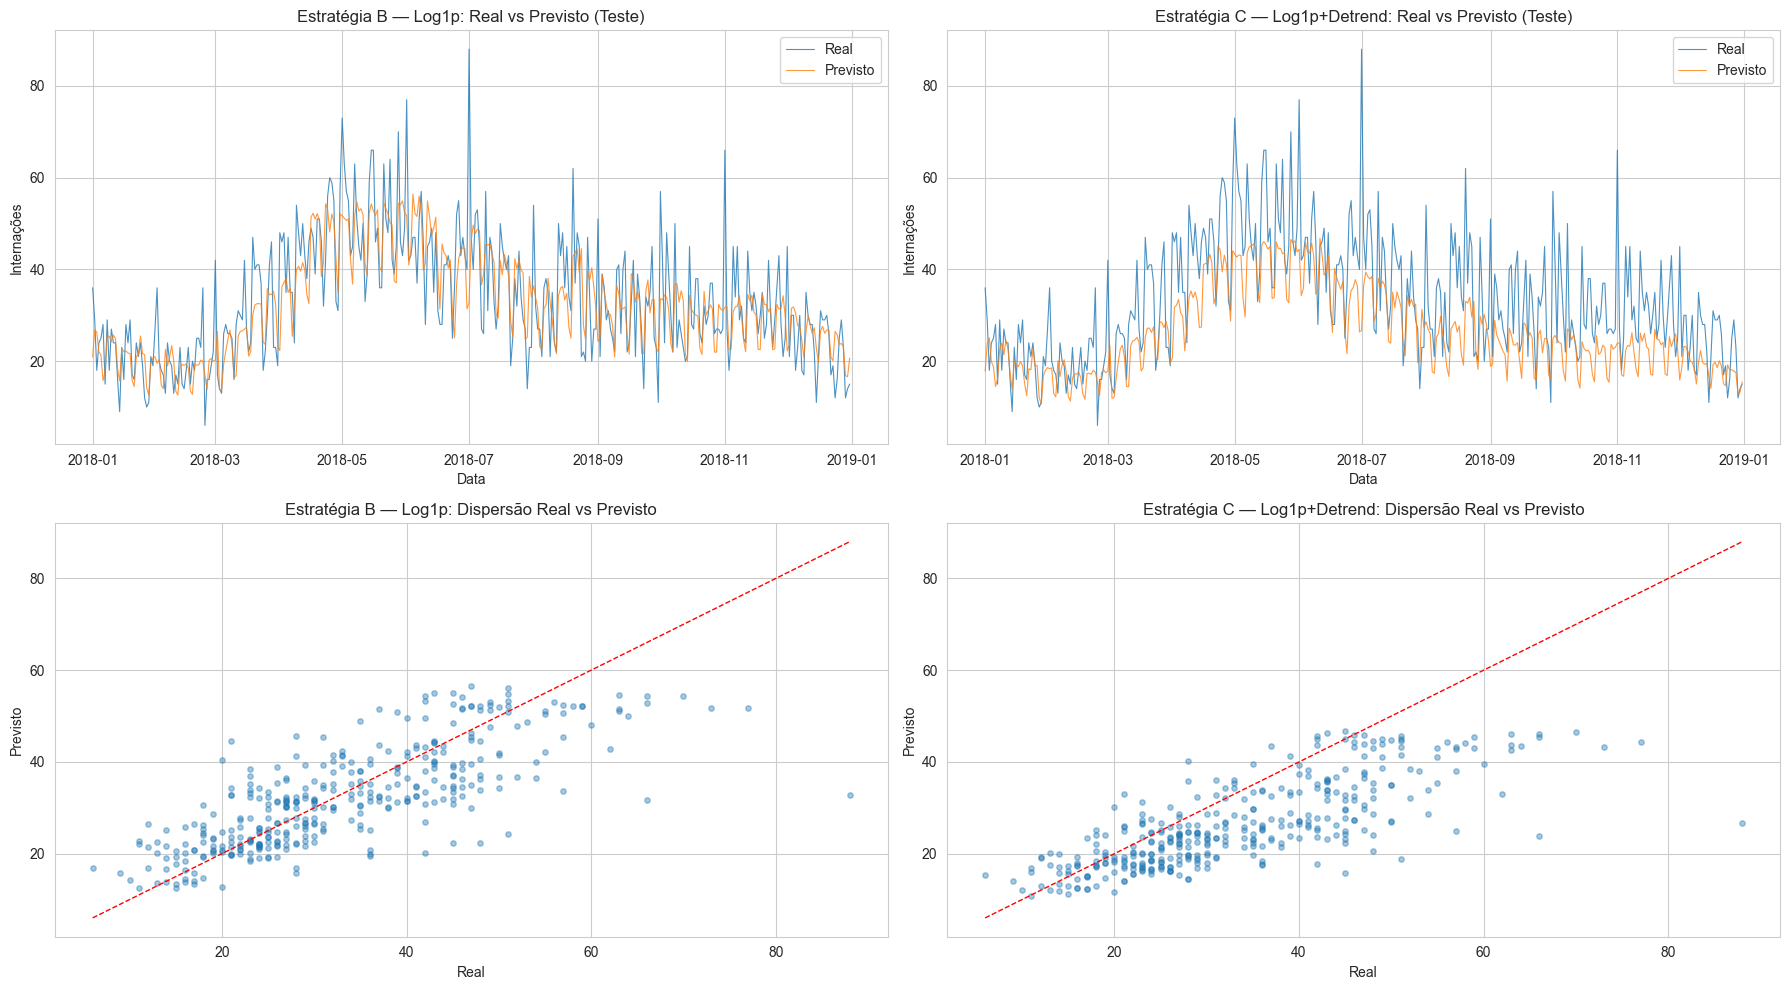

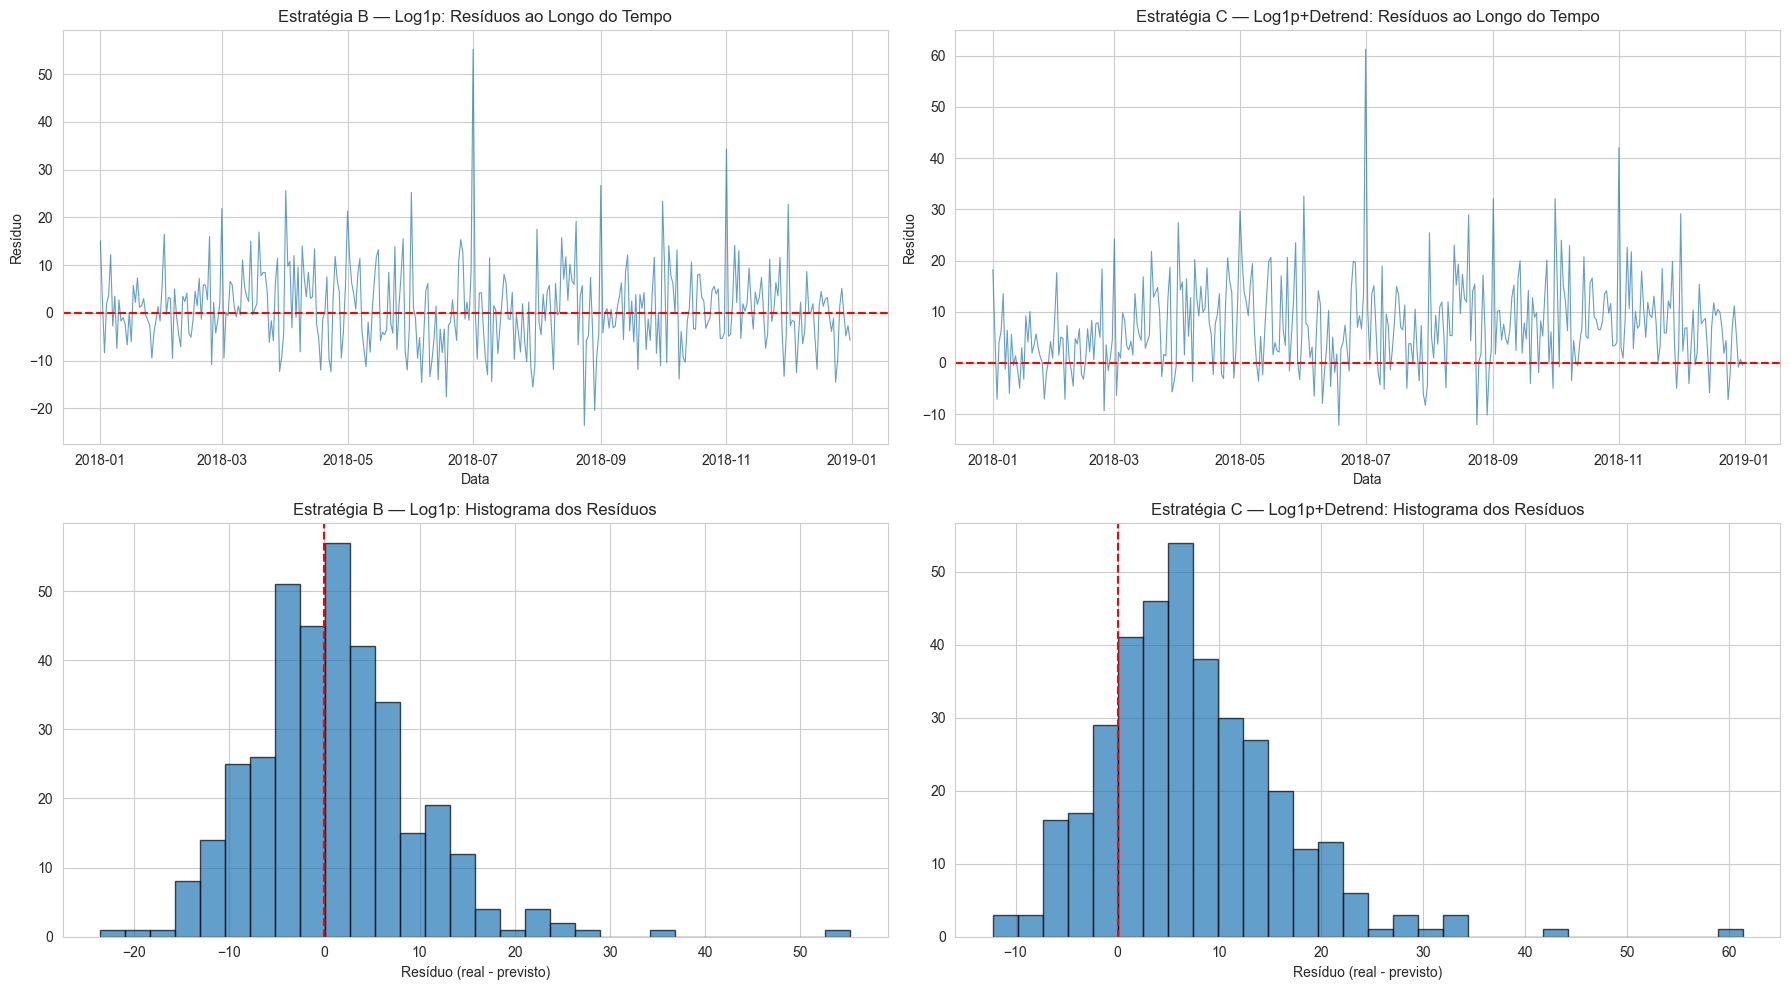

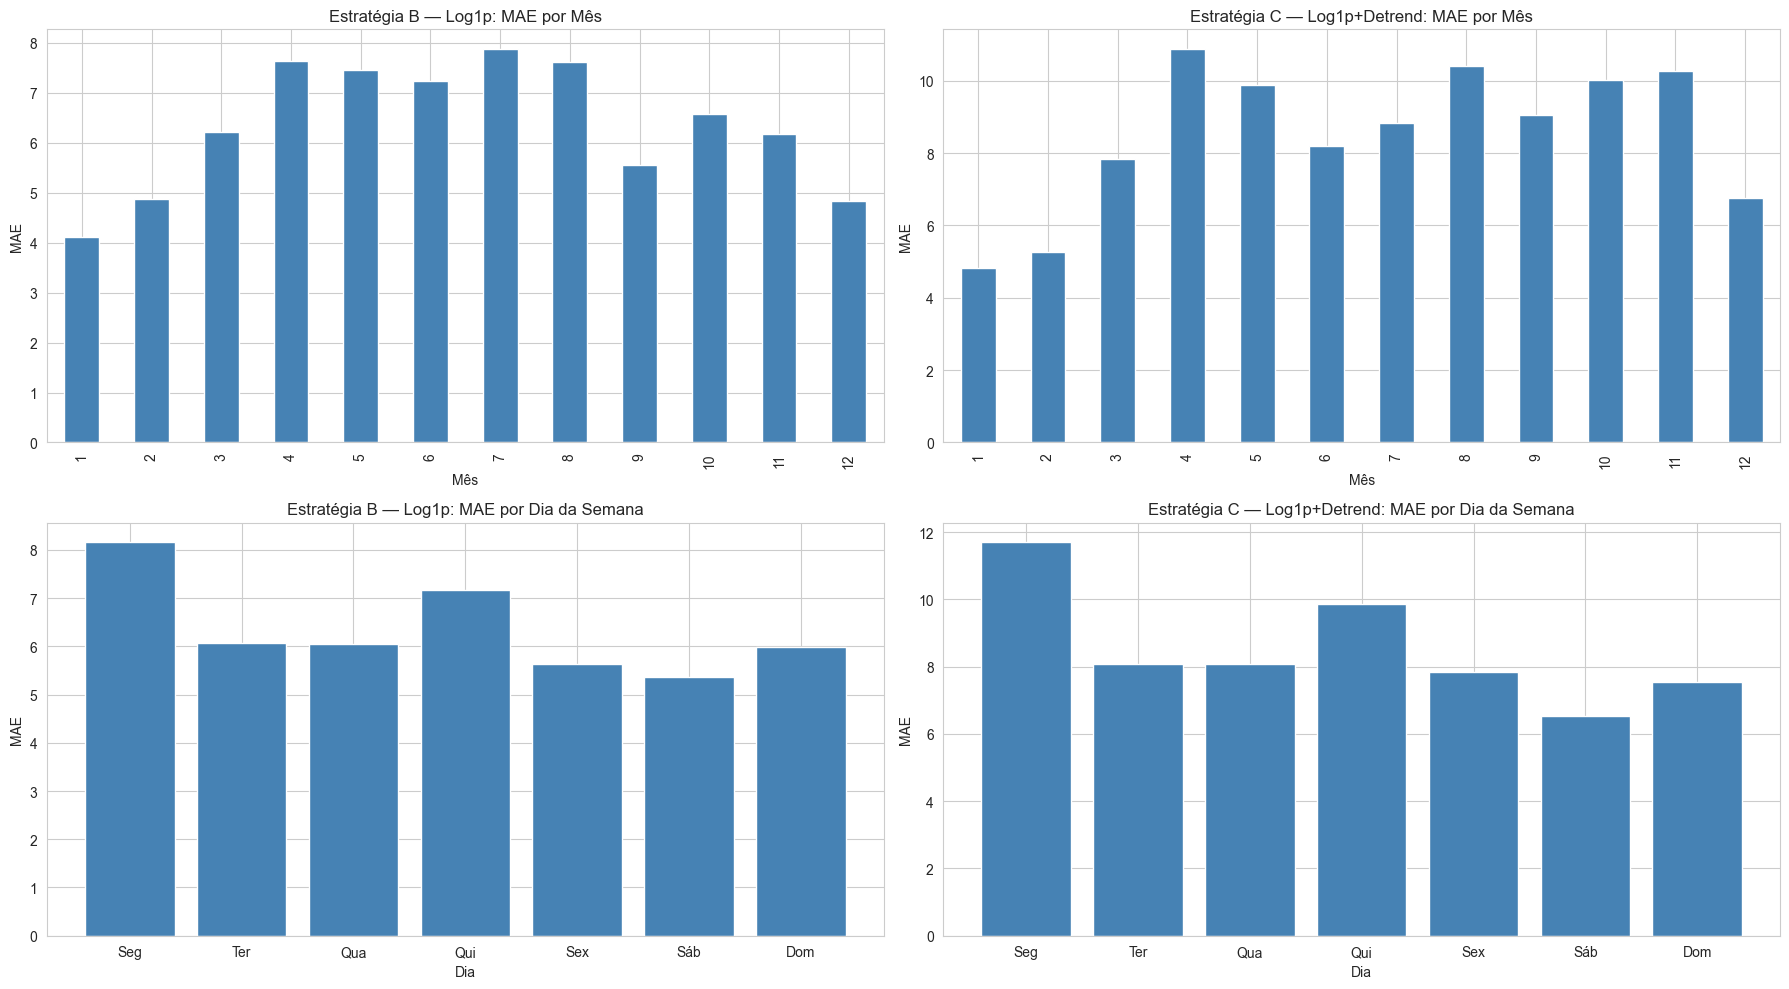

Gráficos de diagnóstico salvos.


In [29]:
modelos = [
    ('B — Log1p',           pred_test_B, metrics_test_B),
    ('C — Log1p+Detrend',   pred_test_C, metrics_test_C),
]

# --- Figura 1: série temporal e dispersão para cada modelo ---
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for col, (label, pred_test, _) in enumerate(modelos):
    # Série temporal
    ax = axes[0, col]
    ax.plot(dates_test.values, y_test.values, label='Real', alpha=0.8, linewidth=0.8)
    ax.plot(dates_test.values, pred_test, label='Previsto', alpha=0.8, linewidth=0.8)
    ax.set_title(f'Estratégia {label}: Real vs Previsto (Teste)')
    ax.set_xlabel('Data')
    ax.set_ylabel('Internações')
    ax.legend()

    # Dispersão
    ax = axes[1, col]
    ax.scatter(y_test.values, pred_test, alpha=0.4, s=15)
    lims = [min(y_test.values.min(), pred_test.min()),
            max(y_test.values.max(), pred_test.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_title(f'Estratégia {label}: Dispersão Real vs Previsto')
    ax.set_xlabel('Real')
    ax.set_ylabel('Previsto')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diagnostico_serie_dispersao.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figura 2: resíduos ao longo do tempo e histograma ---
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for col, (label, pred_test, _) in enumerate(modelos):
    residuals = y_test.values - pred_test

    # Resíduos ao longo do tempo
    ax = axes[0, col]
    ax.plot(dates_test.values, residuals, alpha=0.7, linewidth=0.8)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f'Estratégia {label}: Resíduos ao Longo do Tempo')
    ax.set_xlabel('Data')
    ax.set_ylabel('Resíduo')

    # Histograma dos resíduos
    ax = axes[1, col]
    ax.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f'Estratégia {label}: Histograma dos Resíduos')
    ax.set_xlabel('Resíduo (real - previsto)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diagnostico_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figura 3: MAE por mês e por dia da semana ---
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
dias_nome = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

for col, (label, pred_test, _) in enumerate(modelos):
    df_diag = pd.DataFrame({
        'data': dates_test.values,
        'abs_error': np.abs(y_test.values - pred_test)
    })
    df_diag['mes'] = pd.to_datetime(df_diag['data']).dt.month
    df_diag['dia_semana'] = pd.to_datetime(df_diag['data']).dt.dayofweek

    ax = axes[0, col]
    df_diag.groupby('mes')['abs_error'].mean().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Estratégia {label}: MAE por Mês')
    ax.set_xlabel('Mês')
    ax.set_ylabel('MAE')

    ax = axes[1, col]
    mae_dow = df_diag.groupby('dia_semana')['abs_error'].mean()
    ax.bar(range(7), mae_dow.values, color='steelblue')
    ax.set_xticks(range(7))
    ax.set_xticklabels(dias_nome)
    ax.set_title(f'Estratégia {label}: MAE por Dia da Semana')
    ax.set_xlabel('Dia')
    ax.set_ylabel('MAE')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diagnostico_mae_calendario.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráficos de diagnóstico salvos.')


## 13. Importância das Features

Análise com:
1. **`feature_importances_`** — impureza (MDI)
2. **Permutation importance** — avaliada no conjunto de teste

Calculado e comparado lado a lado para as estratégias **B** e **C**.


In [30]:
# --- Estratégia B ---
print('Calculando feature importance — Estratégia B...')
rf_B = final_pipeline_B.named_steps['rf']
importances_mdi_B = pd.Series(rf_B.feature_importances_, index=feature_cols).sort_values(ascending=False)

perm_B = permutation_importance(
    final_pipeline_B, X_test, y_test,
    n_repeats=15, random_state=SEED, scoring='neg_mean_absolute_error', n_jobs=-1
)
importances_perm_B = pd.Series(perm_B.importances_mean, index=feature_cols).sort_values(ascending=False)

df_importance_B = pd.DataFrame({
    'MDI': importances_mdi_B,
    'Permutation': importances_perm_B,
}).sort_values('Permutation', ascending=False)

# --- Estratégia C ---
print('Calculando feature importance — Estratégia C...')
rf_C = final_pipeline_C.named_steps['rf']
importances_mdi_C = pd.Series(rf_C.feature_importances_, index=feature_cols).sort_values(ascending=False)

perm_C = permutation_importance(
    final_pipeline_C, X_test, y_test,
    n_repeats=15, random_state=SEED, scoring='neg_mean_absolute_error', n_jobs=-1
)
importances_perm_C = pd.Series(perm_C.importances_mean, index=feature_cols).sort_values(ascending=False)

df_importance_C = pd.DataFrame({
    'MDI': importances_mdi_C,
    'Permutation': importances_perm_C,
}).sort_values('Permutation', ascending=False)

print('\n=== Importância das Features — Estratégia B (Log1p) ===')
display(df_importance_B.round(4))
print('\n=== Importância das Features — Estratégia C (Log1p+Detrend) ===')
display(df_importance_C.round(4))


Calculando feature importance — Estratégia B...
Calculando feature importance — Estratégia C...

=== Importância das Features — Estratégia B (Log1p) ===


,MDI,Permutation
lag_3,0.0075,0.0025
lag_7,0.2663,0.0013
lag_21,0.0163,0.0012
lag_28,0.0121,0.0009
no2_lag0,0.0094,0.0001
rolling_mean_7,0.1484,0.0000
lag_30,0.0043,0.0000
dummy_periodo_pico_sazonal,0.0020,-0.0000
rolling_mean_30,0.0474,-0.0001
stl365_season_amp,0.0059,-0.0001



=== Importância das Features — Estratégia C (Log1p+Detrend) ===


,MDI,Permutation
dummy_periodo_pico_sazonal,0.0231,0.0053
lag_21,0.0131,0.0020
lag_3,0.0068,0.0017
lag_28,0.0112,0.0008
mes_cos,0.0350,0.0003
lag_30,0.0047,0.0001
lag_2,0.0049,0.0000
no2_lag0,0.0126,0.0000
no_ma_30d_shift_1d,0.0069,-0.0000
ur_ma_60d_shift_1d,0.0090,-0.0001


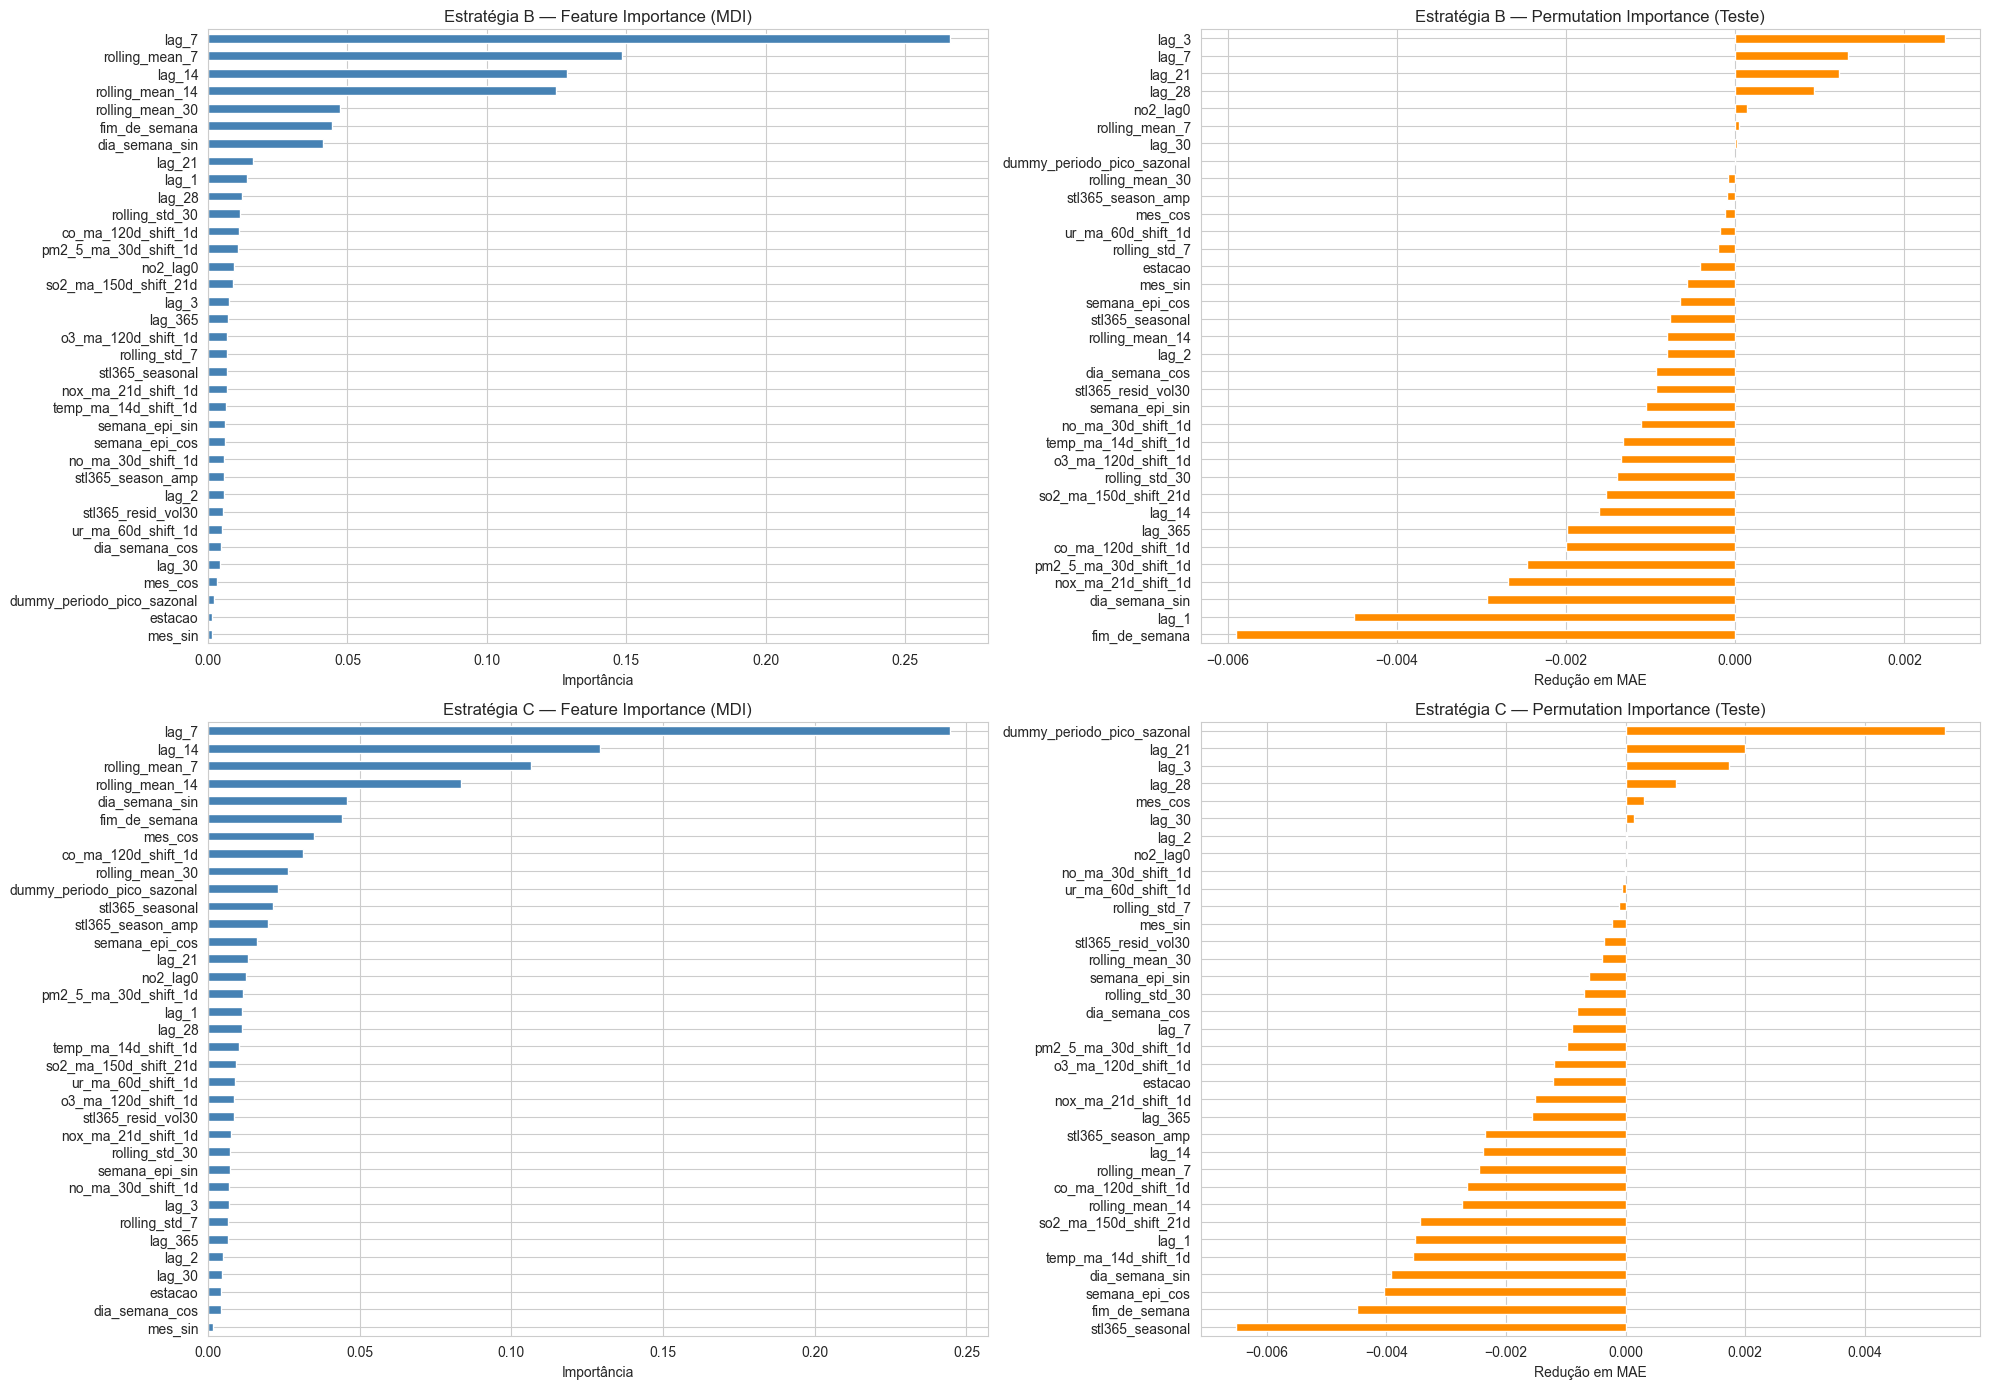

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# B — MDI
importances_mdi_B.sort_values().plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Estratégia B — Feature Importance (MDI)')
axes[0, 0].set_xlabel('Importância')

# B — Permutation
importances_perm_B.sort_values().plot(kind='barh', ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Estratégia B — Permutation Importance (Teste)')
axes[0, 1].set_xlabel('Redução em MAE')

# C — MDI
importances_mdi_C.sort_values().plot(kind='barh', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Estratégia C — Feature Importance (MDI)')
axes[1, 0].set_xlabel('Importância')

# C — Permutation
importances_perm_C.sort_values().plot(kind='barh', ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Estratégia C — Permutation Importance (Teste)')
axes[1, 1].set_xlabel('Redução em MAE')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()


=== Importância por Grupo — Estratégia B ===


,MDI,Permutation
Grupo,,
Umidade,0.0050,-0.0002
Temperatura,0.0063,-0.0013
STL Sazonalidade,0.0178,-0.0018
Médias/Desvios móveis,0.3390,-0.0024
Lags da série,0.4622,-0.0029
Calendário cíclico,0.0623,-0.0063
Calendário/Sazonalidade,0.0479,-0.0063
Poluentes,0.0597,-0.0110



=== Importância por Grupo — Estratégia C ===


,MDI,Permutation
Grupo,,
Umidade,0.0090,-0.0001
Calendário/Sazonalidade,0.0717,-0.0004
Temperatura,0.0101,-0.0036
Lags da série,0.4324,-0.0036
Médias/Desvios móveis,0.2301,-0.0064
STL Sazonalidade,0.0495,-0.0092
Calendário cíclico,0.1096,-0.0093
Poluentes,0.0876,-0.0098


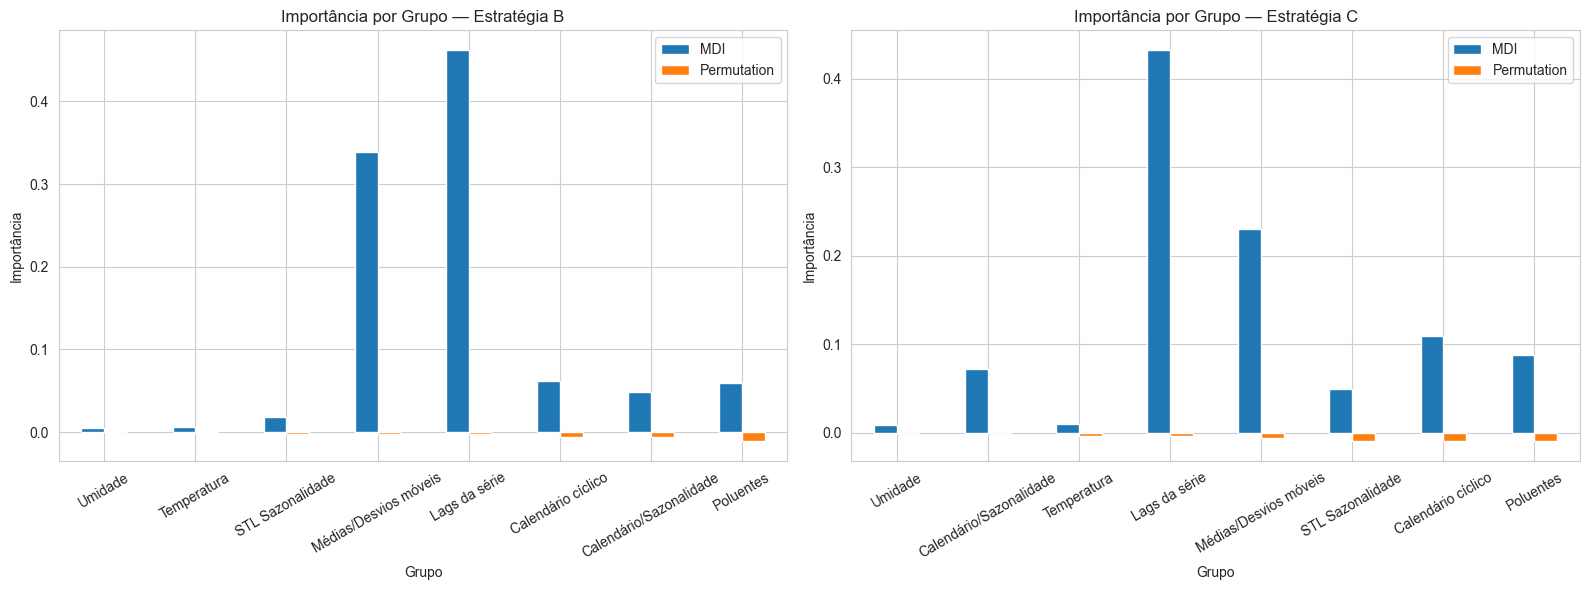

In [32]:
def classify_feature(name):
    """Classifica feature por grupo temático."""
    if name.startswith('lag_'):
        return 'Lags da série'
    if name.startswith('rolling_'):
        return 'Médias/Desvios móveis'
    if name.startswith('stl365'):
        return 'STL Sazonalidade'
    if any(name.startswith(p) for p in ['mes_', 'dia_semana_', 'semana_epi_']):
        return 'Calendário cíclico'
    if name in ['dia_semana', 'fim_de_semana', 'mes', 'semana_epidemiologica',
                'estacao', 'dummy_periodo_pico_sazonal']:
        return 'Calendário/Sazonalidade'
    if name.startswith(('o3', 'no_', 'no2', 'co_', 'so2', 'nox', 'pm')):
        return 'Poluentes'
    if name.startswith('temp'):
        return 'Temperatura'
    if name.startswith('ur'):
        return 'Umidade'
    return 'Outros'

df_importance_B['Grupo'] = df_importance_B.index.map(classify_feature)
df_importance_C['Grupo'] = df_importance_C.index.map(classify_feature)

group_B = df_importance_B.groupby('Grupo')[['MDI', 'Permutation']].sum().sort_values('Permutation', ascending=False)
group_C = df_importance_C.groupby('Grupo')[['MDI', 'Permutation']].sum().sort_values('Permutation', ascending=False)

print('=== Importância por Grupo — Estratégia B ===')
display(group_B.round(4))
print('\n=== Importância por Grupo — Estratégia C ===')
display(group_C.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

group_B.plot(kind='bar', ax=axes[0])
axes[0].set_title('Importância por Grupo — Estratégia B')
axes[0].set_ylabel('Importância')
axes[0].tick_params(axis='x', rotation=30)

group_C.plot(kind='bar', ax=axes[1])
axes[1].set_title('Importância por Grupo — Estratégia C')
axes[1].set_ylabel('Importância')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'importancia_por_grupo.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Salvamento dos Artefatos Finais

In [33]:
# 1. Modelos finais
joblib.dump(final_pipeline_B, OUTPUT_DIR / 'modelo_rf_B.joblib')
joblib.dump(final_pipeline_C, OUTPUT_DIR / 'modelo_rf_C.joblib')
print(f'Modelos salvos: modelo_rf_B.joblib, modelo_rf_C.joblib')

# 2. Tabela de métricas consolidada
df_test_summary.to_csv(OUTPUT_DIR / 'metricas_teste.csv')
print(f'Métricas salvas: metricas_teste.csv')

# 3. Previsões combinadas (B e C lado a lado)
df_predictions = pd.DataFrame({
    'data':       dates_test.values,
    'real':       y_test.values,
    'previsto_B': pred_test_B,
    'previsto_C': pred_test_C,
})
df_predictions['residuo_B'] = df_predictions['real'] - df_predictions['previsto_B']
df_predictions['residuo_C'] = df_predictions['real'] - df_predictions['previsto_C']
df_predictions.to_parquet(OUTPUT_DIR / 'previsoes_teste.parquet', index=False)
print(f'Previsões salvas: previsoes_teste.parquet')

# 4. Importância das features
df_importance_B.to_csv(OUTPUT_DIR / 'importancia_features_B.csv')
df_importance_C.to_csv(OUTPUT_DIR / 'importancia_features_C.csv')
print(f'Importâncias salvas: importancia_features_B.csv, importancia_features_C.csv')

# 5. Metadata de cada modelo
for label, search, best_params, metrics_test, trend in [
    ('B', search_B, best_params_B, metrics_test_B, None),
    ('C', search_C, best_params_C, metrics_test_C, trend_coeffs_final),
]:
    meta = {
        'estrategia_alvo': label,
        'hiperparametros': search.best_params_,
        'periodo_treino': f'{dates_train.min().date()} a {dates_val.max().date()}',
        'periodo_teste': f'{dates_test.min().date()} a {dates_test.max().date()}',
        'n_features': len(feature_cols),
        'features': feature_cols,
        'metricas_teste': metrics_test,
    }
    if trend is not None:
        meta['trend_coeffs'] = trend.tolist()
    joblib.dump(meta, OUTPUT_DIR / f'metadata_modelo_{label}.joblib')

print('Metadata salvo: metadata_modelo_B.joblib, metadata_modelo_C.joblib')
print(f'\n=== Todos os artefatos salvos com sucesso ===')
print(f'Diretório de saída: {OUTPUT_DIR.resolve()}')


Modelos salvos: modelo_rf_B.joblib, modelo_rf_C.joblib
Métricas salvas: metricas_teste.csv
Previsões salvas: previsoes_teste.parquet
Importâncias salvas: importancia_features_B.csv, importancia_features_C.csv
Metadata salvo: metadata_modelo_B.joblib, metadata_modelo_C.joblib

=== Todos os artefatos salvos com sucesso ===
Diretório de saída: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\GoldData\ModelResults


## 15. Resumo Final

Consolidação dos resultados para referência rápida.

In [34]:
print('=' * 70)
print('RESUMO FINAL DA PIPELINE DE MODELAGEM')
print('=' * 70)
print(f'\nModelo: Random Forest Regressor')
print(f'Período de treino: {dates_train.min().date()} a {dates_val.max().date()} (retreino)')
print(f'Período de teste:  {dates_test.min().date()} a {dates_test.max().date()}')
print(f'Número de features: {len(feature_cols)}')

for label, best_params, metrics_test, importances_perm in [
    ('B — Log1p',         best_params_B, metrics_test_B, importances_perm_B),
    ('C — Log1p+Detrend', best_params_C, metrics_test_C, importances_perm_C),
]:
    print(f'\n{"─" * 50}')
    print(f'  Estratégia {label}')
    print(f'{"─" * 50}')
    print(f'  Hiperparâmetros finais:')
    for k, v in best_params.items():
        print(f'    {k}: {v}')
    print(f'  Desempenho no Teste (escala original):')
    print(f'    MAE:   {metrics_test["MAE"]:.2f} internações')
    print(f'    RMSE:  {metrics_test["RMSE"]:.2f} internações')
    print(f'    R²:    {metrics_test["R²"]:.4f}')
    print(f'    sMAPE: {metrics_test["sMAPE"]:.2f}%')
    print(f'  Top 5 features (Permutation Importance):')
    for i, (feat, val) in enumerate(importances_perm.head(5).items(), 1):
        print(f'    {i}. {feat}: {val:.4f}')

print(f'\nArtefatos salvos em: {OUTPUT_DIR.resolve()}')
print('=' * 70)


RESUMO FINAL DA PIPELINE DE MODELAGEM

Modelo: Random Forest Regressor
Período de treino: 2012-06-19 a 2017-12-31 (retreino)
Período de teste:  2018-01-01 a 2018-12-31
Número de features: 35

──────────────────────────────────────────────────
  Estratégia B — Log1p
──────────────────────────────────────────────────
  Hiperparâmetros finais:
    max_depth: None
    max_features: 0.5
    min_samples_leaf: 8
    min_samples_split: 12
    n_estimators: 598
  Desempenho no Teste (escala original):
    MAE:   6.35 internações
    RMSE:  8.62 internações
    R²:    0.5801
    sMAPE: 19.81%
  Top 5 features (Permutation Importance):
    1. lag_3: 0.0025
    2. lag_7: 0.0013
    3. lag_21: 0.0012
    4. lag_28: 0.0009
    5. no2_lag0: 0.0001

──────────────────────────────────────────────────
  Estratégia C — Log1p+Detrend
──────────────────────────────────────────────────
  Hiperparâmetros finais:
    max_depth: 30
    max_features: 0.5
    min_samples_leaf: 8
    min_samples_split: 6
    n_es